# Assignment 3

In [1]:
import seaborn as sns
sns.set(style="darkgrid")

In [2]:
import numpy as np
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
data=sns.load_dataset("titanic")
data.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [6]:
data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
plt.rcParams['figure.figsize']=(6,6)

## Question 1

### Countplot: Passenger Count by Embarked Port

● Create a countplot to display the number of passengers who boarded from each port (embarked), separated by sex.

In [8]:
data1=data.dropna(subset=['embarked','sex'])

In [9]:
data1[['embarked','sex']].isnull().sum()

embarked    0
sex         0
dtype: int64

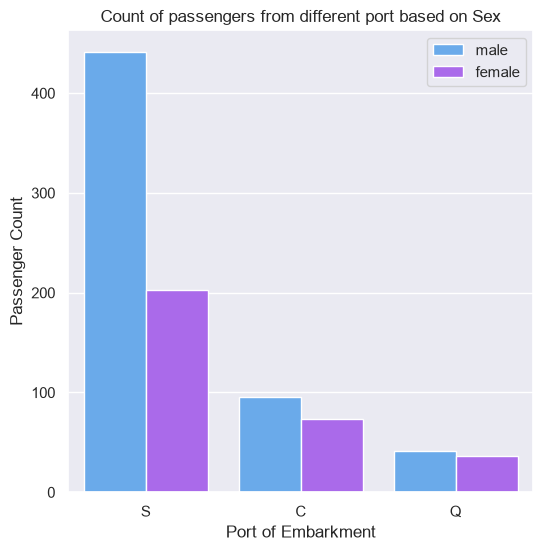

In [10]:
sns.countplot(x='embarked',data=data1,hue='sex',palette='cool')
plt.title('Count of passengers from different port based on Sex')
plt.xlabel('Port of Embarkment')
plt.ylabel('Passenger Count')
plt.legend()
plt.show()

## Question 2

### Swarmplot: Age Distribution across Classes

● Create a swarmplot to visualize the distribution of age across passenger classes (pclass), categorized by sex.

In [11]:
data2=data.dropna(subset=['pclass','age','sex'])

In [12]:
data2[['pclass','age','sex']].isnull().sum()

pclass    0
age       0
sex       0
dtype: int64

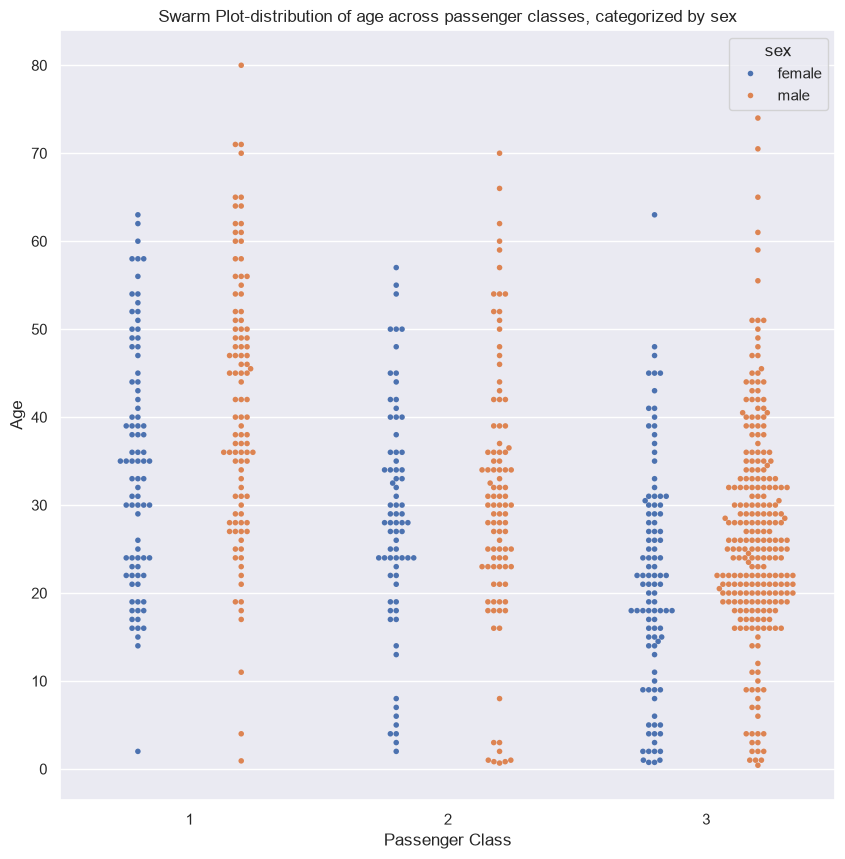

In [14]:
plt.figure(figsize=(10,10))
sns.swarmplot(x='pclass',y='age',data=data2,s=4, hue='sex',dodge=True)
plt.title('Swarm Plot-distribution of age across passenger classes, categorized by sex')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.show()

Or

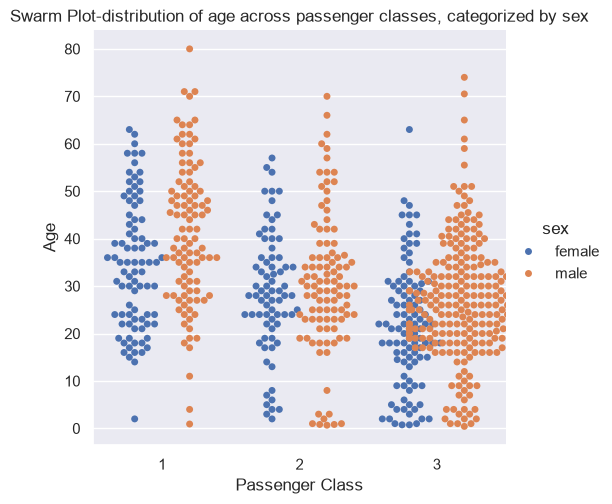

In [15]:
sns.catplot(x='pclass',y='age',kind='swarm',data=data2,hue='sex',dodge=True);
plt.title('Swarm Plot-distribution of age across passenger classes, categorized by sex')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.show()

## Question 3

### Pie Chart: Gender Distribution

● Create a pie chart using Matplotlib to show the percentage of male vs. female passengers. - Add percentage labels using autopct - Use explode for one slice to highlight it.

In [16]:
count=data['sex'].value_counts()
count

sex
male      577
female    314
Name: count, dtype: int64

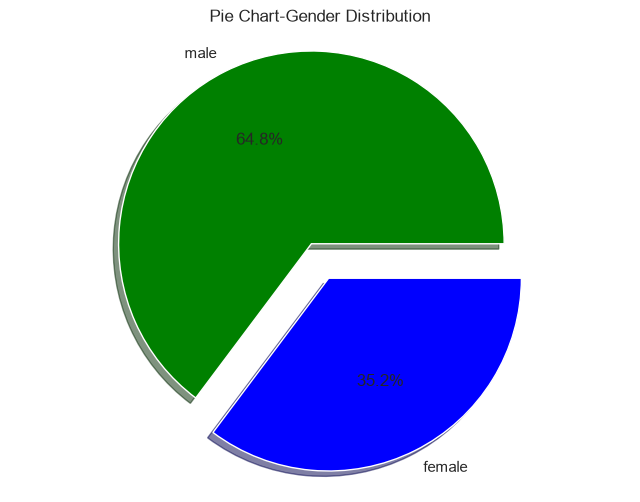

In [17]:
plt.figure(figsize=(8,6))
plt.pie(count,labels=count.index, autopct='%.1f%%',explode=[0,0.2],shadow=True,colors=(['Green','Blue']))
plt.title('Pie Chart-Gender Distribution')
plt.axis('equal')    
plt.show()

Or

In [18]:
data3=data.groupby(['sex']).size().reset_index(name='count')

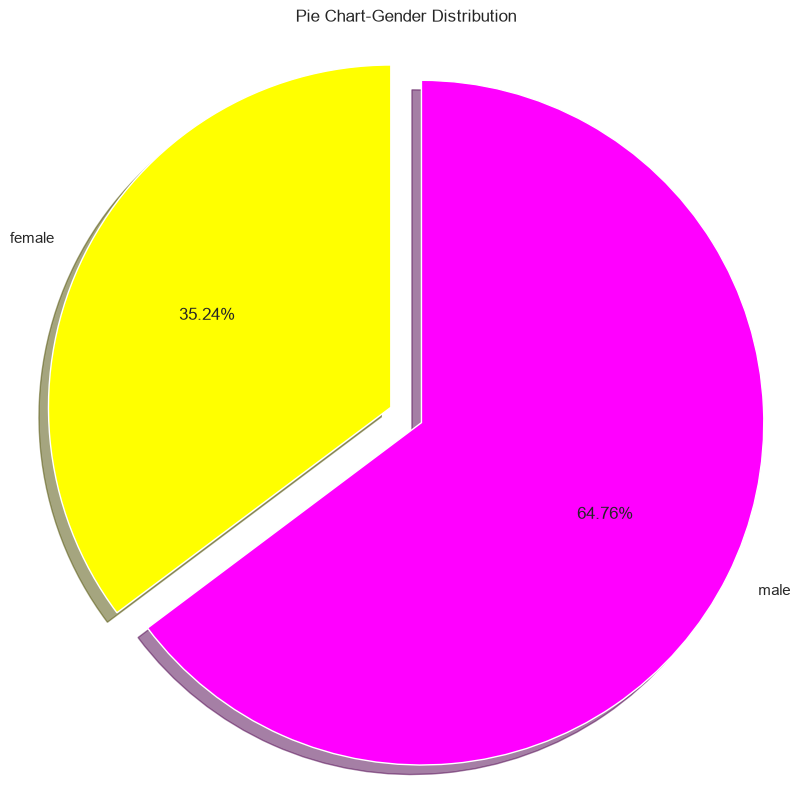

In [19]:
plt.figure(figsize=(10,10))
plt.pie(data3['count'],labels=data3['sex'], autopct='%.2f%%',explode=[0.1,0],shadow=True,colors=(['yellow','magenta']),startangle=90)
plt.title('Pie Chart-Gender Distribution')
plt.axis('equal')    
plt.show()

## Question 4

### Heatmap: Correlation Matrix

● Create a heatmap to show correlations between age, fare, pclass, sibsp, parch, and survived. (Use seaborn.heatmap with annotations)

In [20]:
data4=data.dropna(subset=['age'])

In [21]:
data4[['pclass','age','fare','sibsp','parch','survived']].isnull().sum()

pclass      0
age         0
fare        0
sibsp       0
parch       0
survived    0
dtype: int64

In [22]:
data4=data.select_dtypes(include='number')
data4.head(3)

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250


In [23]:
corr=data4.corr()
corr

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


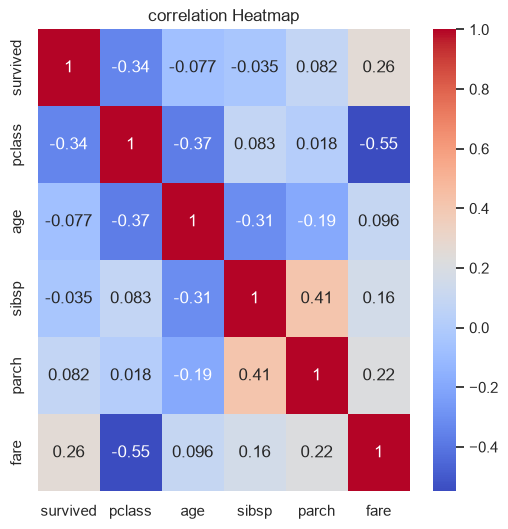

In [24]:
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('correlation Heatmap')
plt.show()

## Question 5

### Violin Plot: Fare by Class and Gender 

● Create a violin plot to visualize fare distribution across classes, separated by gender.

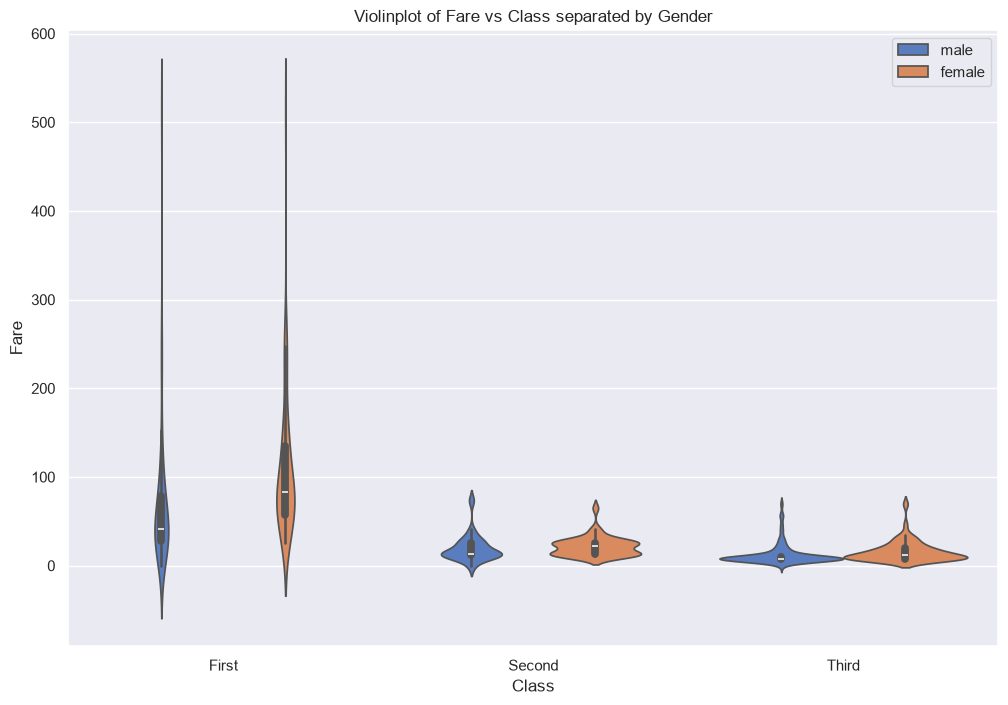

In [25]:
plt.figure(figsize=(12,8))
sns.violinplot(x='class',y='fare',hue='sex',data=data,palette='muted')
plt.title('Violinplot of Fare vs Class separated by Gender')
plt.xlabel('Class')
plt.ylabel('Fare')
plt.legend()
plt.show()

## Question 6

### Scatter Plot: Age vs Fare 

● Create a scatter plot to explore the relationship between age and fare, colored by survival status. 
● Use a seaborn scatterplot with hue='survived'. Each plot must have titles, labels, and legends where needed.

In [26]:
data6=data.dropna(subset=['age','fare','survived'])

In [27]:
data6[['age','fare','survived']].isnull().sum()

age         0
fare        0
survived    0
dtype: int64

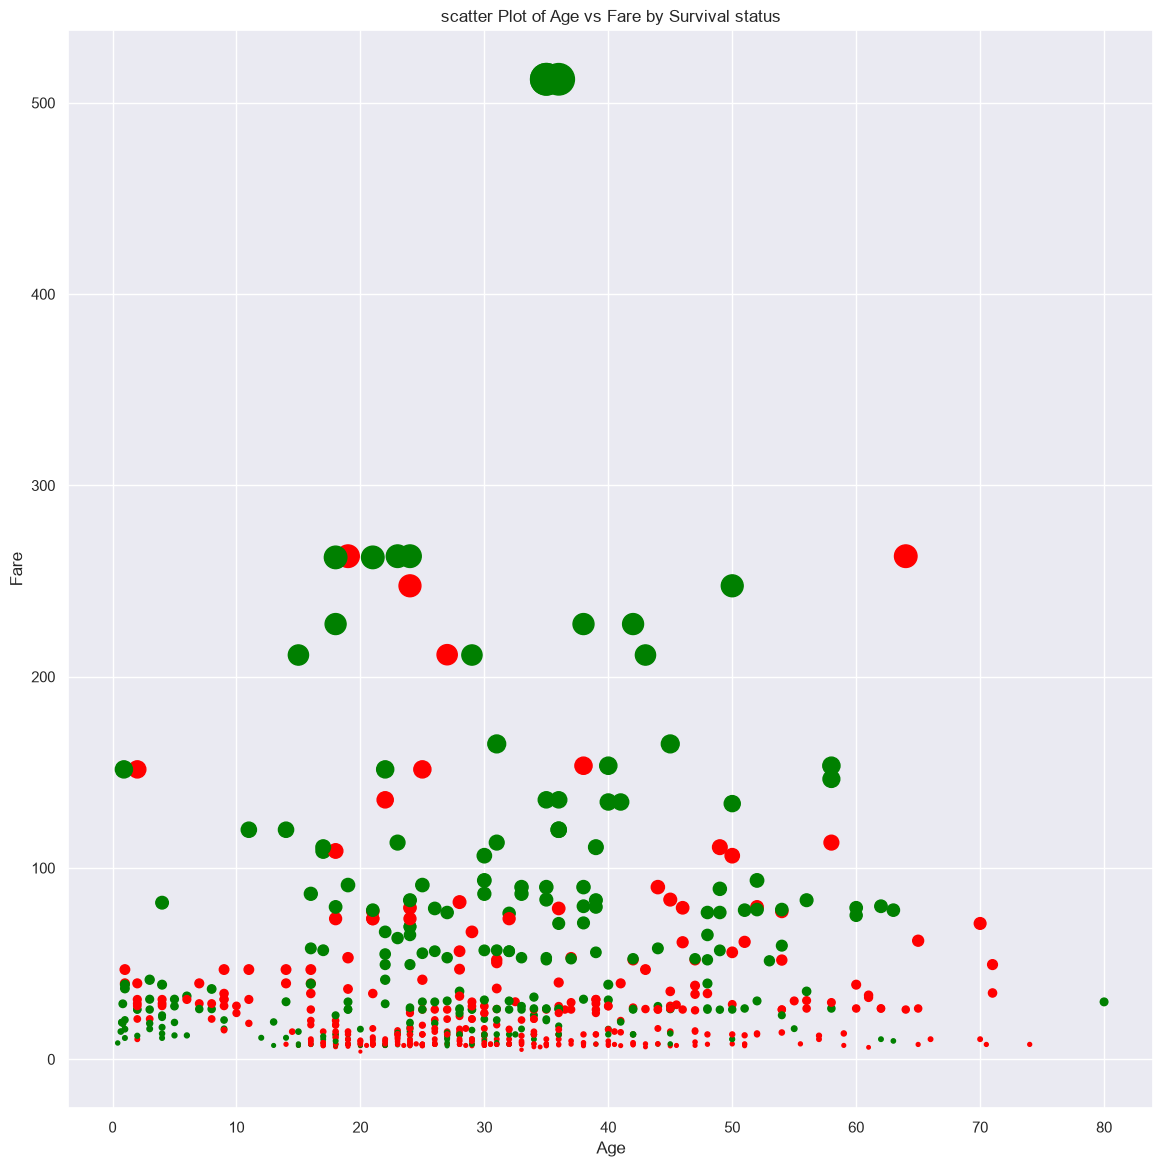

In [30]:
plt.figure(figsize=(14,14))
colors = ['red' if x == 0 else 'Green'for x in data6['survived'] ]
plt.scatter(data6['age'], data6['fare'], s=data6['fare'],c=colors)
plt.title('scatter Plot of Age vs Fare by Survival status')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

Or

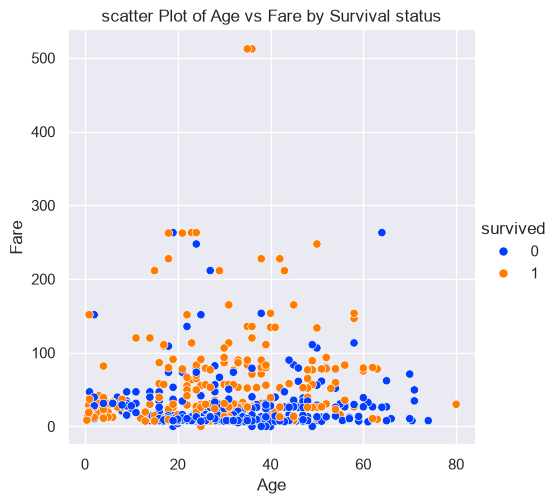

In [32]:
sns.relplot(x='age',y='fare', data=data6, hue='survived',palette='bright',kind="scatter");
plt.title('scatter Plot of Age vs Fare by Survival status')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()